In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
# Load raw PaySim dataset [cite: 52]
df_paysim = pd.read_csv('../data/raw/paysim.csv')
df_paysim.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


C:\Users\vivek\AppData\Local\Temp\ipykernel_8656\3822827985.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_paysim, x='type', palette='viridis')


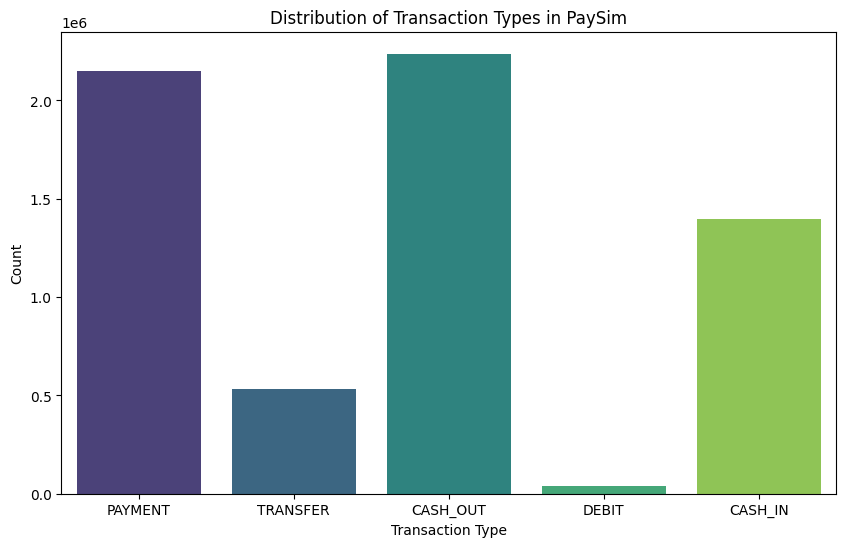

In [3]:
# Visualize the types of transactions occurring in the dataset
plt.figure(figsize=(10, 6))
sns.countplot(data=df_paysim, x='type', palette='viridis')
plt.title('Distribution of Transaction Types in PaySim')
plt.ylabel('Count')
plt.xlabel('Transaction Type')
plt.show()

In [4]:
# Create a temporary feature to see how often accounts hit zero
df_paysim['hit_zero'] = df_paysim['newbalanceOrig'] == 0
zero_bal_counts = df_paysim.groupby('type')['hit_zero'].sum()

print("Transactions resulting in a zero balance:")
print(zero_bal_counts[zero_bal_counts > 0])

Transactions resulting in a zero balance:
type
CASH_OUT    1985211
DEBIT         11786
PAYMENT     1101124
TRANSFER     511445
Name: hit_zero, dtype: int64
